In [3]:
from scipy import stats
import pandas as pd
import pandas_datareader as web
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
import yfinance as yf

In [2]:
start=datetime.datetime(2021,1,1)
end=datetime.datetime(2022,1,1)

In [4]:
df_nifty=yf.download("^NSEI",start,end)
df_nifty.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-01,13996.099609,14049.849609,13991.349609,14018.500000,14018.500000,358100
2021-01-04,14104.349609,14147.950195,13953.750000,14132.900391,14132.900391,495000
2021-01-05,14075.150391,14215.599609,14048.150391,14199.500000,14199.500000,492500
2021-01-06,14240.950195,14244.150391,14039.900391,14146.250000,14146.250000,632300
2021-01-07,14253.750000,14256.250000,14123.099609,14137.349609,14137.349609,559200


In [5]:
df_b=yf.download("M&M.NS",start,end)
df_b.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-01,725.0,744.750000,723.000000,732.450012,697.082214,9543128
2021-01-04,735.0,751.000000,727.250000,749.099976,712.928223,4547027
2021-01-05,748.0,748.000000,730.000000,740.099976,704.362793,3551554
2021-01-06,741.0,746.450012,730.450012,736.099976,700.556030,3601608
2021-01-07,743.0,755.000000,740.099976,744.400024,708.455200,4063641


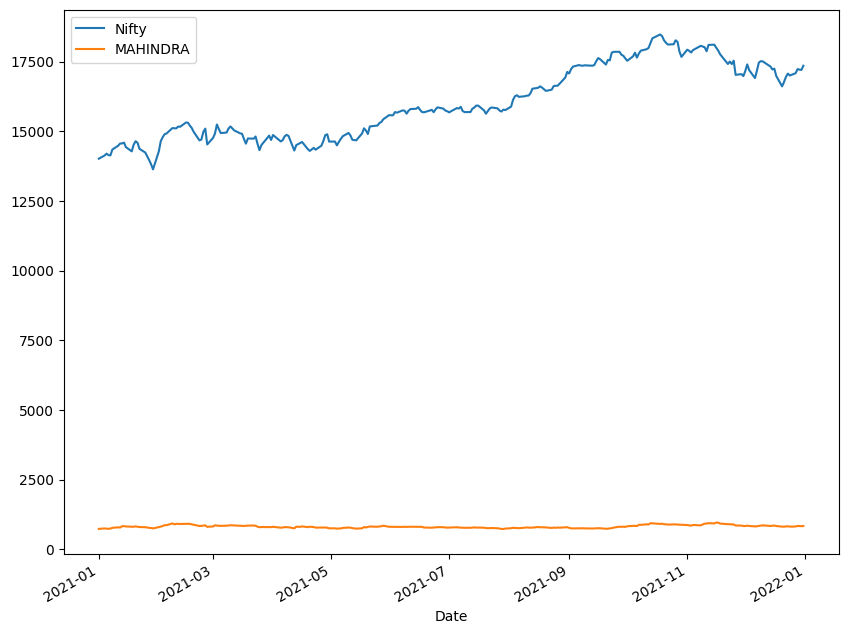

In [6]:
df_nifty['Close'].plot(label = 'Nifty', figsize=(10,8) )
df_b['Close'].plot(label = 'MAHINDRA')
plt.legend()

In [7]:
df_nifty['cum']=df_nifty["Close"]/df_nifty["Close"].iloc[0]
df_b['cum']=df_b["Close"]/df_b["Close"].iloc[0]

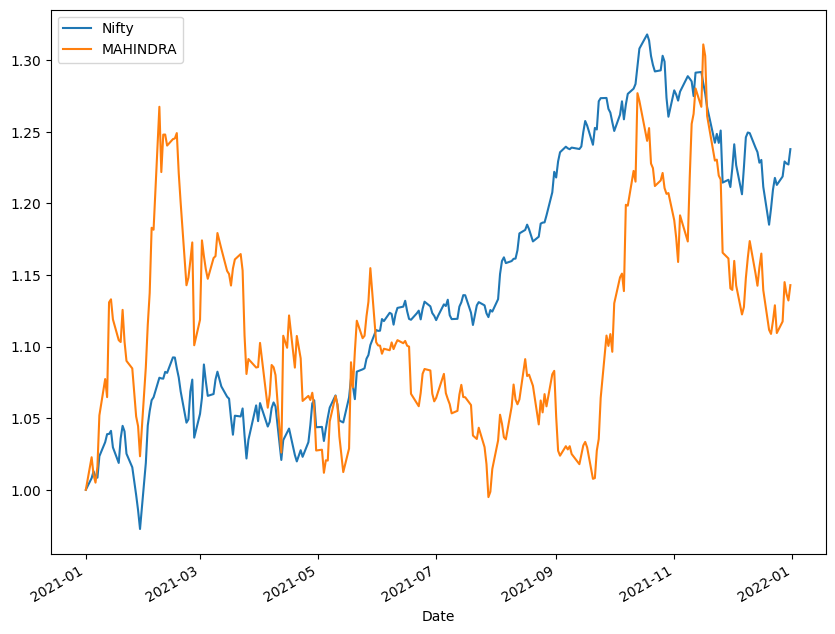

In [8]:
df_nifty['cum'].plot(label = 'Nifty', figsize=(10,8))
df_b['cum'].plot(label = 'MAHINDRA')
plt.legend()

In [9]:
df_nifty['daily_ret'] = df_nifty['Close'].pct_change(1)
df_b['daily_ret'] = df_b['Close'].pct_change(1)

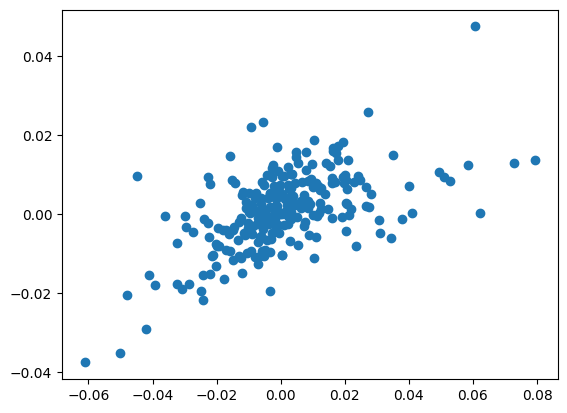

In [10]:
plt.scatter(df_b['daily_ret'],df_nifty['daily_ret'])

In [11]:
LR = stats.linregress(df_b['daily_ret'].iloc[1:],df_nifty['daily_ret'].iloc[1:])
LR

LinregressResult(slope=0.28689878757048065, intercept=0.0007025289508417105, rvalue=0.5740918909816681, pvalue=4.6968842190290815e-23, stderr=0.026141906286282473, intercept_stderr=0.0005161479613729546)

In [12]:
beta,alpha,r_val,p_val,std_err = LR

In [13]:
beta,alpha,r_val,p_val,std_err

(0.28689878757048065,
 0.0007025289508417105,
 0.5740918909816681,
 4.6968842190290815e-23,
 0.026141906286282473)

In [20]:
date1=datetime.datetime(2022,7,19)
date2=datetime.datetime(2022,7,20)

In [15]:
rm = (df_nifty['Close'].iloc[-1]-df_nifty['Close'].iloc[0])/df_nifty['Close'].iloc[0]
rm

0.2379392075650034

In [16]:
rf=0.055 #fd return of sbi taken as risk free return
rf

0.055

In [17]:
smb=0.15
hml=0.17

In [18]:
expected_return_capm= 1+beta*(rm-rf)
expected_return_capm

1.052485036849504

In [21]:
df_mah=yf.download("M&M.NS",date1,date2)
df_mah

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-07-19,1161.900024,1189.5,1161.0,1186.25,1153.358521,4056414


In [22]:
actual_return=df_mah['Close'].iloc[0]/df_b['Close'].iloc[0]
actual_return

1.6195644483991074

In [23]:
err_capm=(actual_return-expected_return_capm)/actual_return
err_capm

0.35014315861906264

In [24]:
expected_return_fama=1+beta*(rm-rf)+r_val*smb+p_val*hml+alpha
expected_return_fama

1.139301349447596

In [25]:
err_fama=(expected_return_fama-actual_return)/actual_return
err_fama

-0.2965384300860873

In [26]:
# It can be seen that return in fama-french Three_Factor model is less than CAPM model.